In [90]:
import numpy as np
import pandas as pd
import gurobipy as grb
from gurobipy import GRB

import matplotlib.pyplot as plt

In [91]:
# 创建一个空的模型
model = grb.Model("Integrated_Energy_System")
model.setParam("OutputFlag", 0)
# 定义模型中的参数
# 时间步数，假设24小时
T = 24

# 设备功率和效率等参数（单位：MW 或者单位功率）
# 电解槽（EL）参数
PEL_max = 5  # 电解槽最大功率（MW）
ηEL = 0.75  # 电解槽效率
meh = 0.03954  # 氢气的热值（MWh/kg）
ΔPEL_up = 0.2  # 电解槽爬坡上限比例（MW）
ΔPEL_down = -0.2  # 电解槽爬坡下限（MW）
αEL = 25  # 电解槽运营和维护成本（¥/MWh）

# 氢燃料电池（HFC）参数
HHFC_max = 25  # 氢燃料电池最大功率（kg/h）
ηHFC = 0.95  # 氢燃料电池效率
ηHFC_e = 0.8  # 氢燃料电池电效率
ηHFC_h = 0.15  # 氢燃料电池热效率
ΔHHFC_up = 0.2  # 氢燃料电池功率爬坡上限比例（kg/h）
ΔHHFC_down = -0.2  # 氢燃料电池功率爬坡下限（kg/h）
αHFC = 18  # 氢燃料电池运营和维护成本（¥/MWh）

# 余热锅炉（WHB）参数
PWHB_max = 600  # 余热锅炉最大功率（MW）
ηWHB = 0.75  # 余热锅炉效率
αWHB = 65  # 余热锅炉运营和维护成本（¥/MWh）

αWT = 70  # 风力发电机运营和维护成本（¥/MWh）
αPV = 32  # 光伏发电运营和维护成本（¥/MWh）

# 燃气轮机（GT）参数
PGT_max = 580  # 燃气轮机最大功率（MW）
ηGT = 0.35  # 燃气轮机效率
ηloss = 0.1  # 能量损失率
ΔPGT_up = 0.2  # 燃气轮机爬坡上限比例（MW）
ΔPGT_down = -0.2  # 燃气轮机爬坡下限（MW）
αGT = 12.5  # 燃气轮机运营和维护成本（¥/MWh）

# 燃气锅炉（GB）参数
PGB_max = 1000  # 燃气锅炉最大功率（MW）
ηGB = 0.75  # 燃气锅炉效率
ΔPGB_up = 0.2  # 燃气锅炉爬坡上限比例（MW）
ΔPGB_down = -0.2  # 燃气锅炉爬坡下限（MW）
αGB = 85  # 燃气锅炉运营和维护成本（¥/MWh）

# 甲烷发生器（MR）参数
HMR_max = 1000      # 甲烷发生器最大耗氢量（kg/h）
ηMR = 0.6           # 甲烷发生器效率
ΔHMR_up = 0.2       # 甲烷发生器爬坡上限比例（kg/h）
ΔHMR_down = -0.2    # 甲烷发生器爬坡下限比例（kg/h）
αMR = 19            # 甲烷发生器运营维护成本（¥/MWh）

# MR 碳利用系数（捕集的 CO2 用于甲烷合成）
θ = 0.00135         # CO2 利用系数
lambda_carbon = 250   # 碳交易基准价格（¥/t）
l_carbon = 100        # 阶梯区间长度（t）
alpha_carbon = 0.25   # 阶梯价格增长率

# 碳捕集系统（CCS）参数
ηCCS = 0.65      # CCS捕集效率
eccs = 0.269     # 单位CO2捕集耗电量（MWh/t）
kcs = 1.4        # 单位CO2封存成本（¥/t）
αCCS = 55        # CCS运行维护成本（¥/MWh）

# 初始碳配额系数（kg/kWh）
kappa_buy = 0.68      # 购电碳配额系数
kappa_GT = 0.612      # GT 碳配额系数
kappa_GB = 0.306      # GB 碳配额系数

# 实际碳排放系数（kg/kWh）
kappa_buy_a = 1.08    # 购电实际碳排放系数
kappa_GT_e = 0.195    # GT 发电实际碳排放系数
kappa_GT_h = 0.39     # GT 供热实际碳排放系数
kappa_GB_a = 0.195    # GB 实际碳排放系数


heat_price = 1000     # 外购热价（¥/MWh）

# 电储能（ES1）参数
Pmax_cha1 = 60  # 电储能充电最大功率（MW）
Pmax_dis1 = 60  # 电储能放电最大功率（MW）
Smin1 = 40  # 电储能最小容量（MWh）
Smax1 = 180  # 电储能最大容量（MWh）
ηcha_ES1 = 0.95  # 电储能充电效率
ηdis_ES1 = 0.95  # 电储能放电效率
α1 = 18  # 电储能的运行维护成本（¥/MWh）

# 热储能（ES2）参数
Pmax_cha2 = 60  # 热储能充电最大功率（MW）
Pmax_dis2 = 60  # 热储能放电最大功率（MW）
Smin2 = 40  # 热储能最小容量（MW）
Smax2 = 180  # 热储能最大容量（MW）
ηcha_ES2 = 0.95  # 热储能充电效率
ηdis_ES2 = 0.95  # 热储能放电效率
α2 = 16  # 热储能的运营维护成本（¥/MWh）

# 气储能（ES3）参数
Pmax_cha3 = 30  # 气储能充电最大功率（MW）
Pmax_dis3 = 30  # 气储能放电最大功率（MW）
Smin3 = 20  # 气储能最小容量（MW）
Smax3 = 90  # 气储能最大容量（MW）
ηcha_ES3 = 0.95  # 气储能充电效率
ηdis_ES3 = 0.95  # 气储能放电效率
α3 = 16  # 气储能的运营维护成本（¥/MWh）

# 氢储能（ES4）参数
Pmax_cha4 = 300  # 氢储能充电最大功率（kg/h）
Pmax_dis4 = 300  # 氢储能放电最大功率（kg/h）
Smin4 = 200  # 氢储能最小容量（kg）
Smax4 = 900  # 氢储能最大容量（kg）
ηcha_ES4 = 0.95  # 氢储能充电效率
ηdis_ES4 = 0.95  # 氢储能放电效率
α4 = 16  # 氢储能的运行维护成本（¥/kg）

# ========= 电价（¥/MWh），24 小时序列 =========
# 原始电价（¥/kWh）× 1000 → ¥/MWh
electricity_price = [
    343.8, 343.8, 343.8, 343.8, 343.8, 343.8, 343.8,   # 0:00–7:00
    680.0, 680.0, 680.0, 680.0,                        # 7:00–11:00
    811.0, 811.0, 811.0,                               # 11:00–14:00
    680.0, 680.0, 680.0,                               # 14:00–17:00
    811.0, 811.0, 811.0, 811.0, 811.0,                 # 17:00–22:00
    380.0, 380.0                                      # 22:00–24:00
]

# 氢气价格（¥/MWh）
hydrogen_price = 1500  # 氢气单价（¥/MWh）

# 天然气价格（¥/MWh）
natural_gas_price = 350  # 天然气单价（¥/MWh）
heat_price = 1000     # 外购热价（¥/MWh）
# 风电和光伏的弃电惩罚成本（¥/MWh）
wind_penalty = 200  # 风电弃电惩罚（¥/MWh）
solar_penalty = 200  # 光伏弃电惩罚（¥/MWh）

# 系统负荷（假设为占位）
electric_load = [15, 25, 26, 28, 28, 32, 35, 41, 43, 49, 55, 68, 66, 56, 43, 42, 47, 51, 53, 54, 50, 39, 30, 27]
thermal_load = [45, 24, 38, 48, 51, 58, 43, 58, 68, 83, 80, 84, 70, 68, 65, 62, 65, 88, 50, 48, 45, 55, 63, 50]
hydrogen_load = [80, 66, 60, 50, 50, 55, 55, 100, 152, 136, 80, 70, 70, 70, 90, 90, 80, 70, 70, 70, 70, 70, 70, 70]
gas_load =  [10, 13, 12, 11, 14, 15, 14, 15, 13, 10, 12, 15, 15, 15, 14, 13, 11, 11, 12, 12, 13, 10, 9, 8]


In [92]:
# =========================
# 0) 时间步长（默认 1 小时）
# =========================
dt = 1.0  # hour

# =========================
# 1) 可再生出力上限
# =========================
WT_avail =[20, 33, 36, 46, 47, 43, 40, 50, 38, 34, 48, 31, 38, 29, 11, 8, 32, 47, 33, 42, 52, 50, 59, 42.5]
PV_avail = [0, 0, 0, 0, 0, 0, 0, 0, 0, 17, 30, 40, 45, 46, 43, 33, 21, 8, 0, 0, 0, 0, 0, 0]  # 每小时光伏可用出力上限（MW）

# =========================
# 2) 统一“比例爬坡”参数
# =========================
ramp_GT  = abs(ΔPGT_up)
ramp_GB  = abs(ΔPGB_up)
ramp_EL  = abs(ΔPEL_up)
ramp_HFC = abs(ΔHHFC_up)
ramp_MR = abs(ΔHMR_up)
# =========================
# 3) 变量定义
# =========================
# ---- 外购（无上限，仅非负）----
Pbuy_e = model.addVars(T, lb=0.0, name="Pbuy_e")   # 外购电（MW）
Pbuy_g = model.addVars(T, lb=0.0, name="Pbuy_g")   # 外购天然气（MW）
Pbuy_H = model.addVars(T, lb=0.0, name="Pbuy_H")   # 外购氢（kg/h）  
Pbuy_h = model.addVars(T, lb=0.0, name="Pbuy_h")  # 外购热（MW）

delta_S = model.addVars([1,2,3,4], lb=0.0, name="delta_S")  # 1=电/2=热/3=气/4=氢
# ---- 可再生与弃电 ----
PWT     = model.addVars(T, lb=0.0, name="PWT")      # 实际风电利用（MW）
PWT_cut = model.addVars(T, lb=0.0, name="PWT_cut")  # 风电弃电（MW）
PPV     = model.addVars(T, lb=0.0, name="PPV")      # 实际光伏利用（MW）
PPV_cut = model.addVars(T, lb=0.0, name="PPV_cut")  # 光伏弃电（MW）

# ---- GT：电功率/气输入/热输出 ----
PGT_e = model.addVars(T, lb=0.0, ub=PGT_max, name="PGT_e")  # GT发电（MW）
PGT_g = model.addVars(T, lb=0.0, name="PGT_g")              # GT耗气（MW）
PGT_h = model.addVars(T, lb=0.0, name="PGT_h")              # GT产热（MW）

# ---- GB：热功率/气输入 ----
PGB_h = model.addVars(T, lb=0.0, ub=PGB_max, name="PGB_h")  # GB产热（MW）
PGB_g = model.addVars(T, lb=0.0, name="PGB_g")              # GB耗气（MW）

# ---- WHB：回收热 ----
PWHB_h = model.addVars(T, lb=0.0, ub=PWHB_max, name="PWHB_h")  # WHB回收热（MW）

# ---- EL：耗电与产氢 ----
PEL_e = model.addVars(T, lb=0.0, ub=PEL_max, name="PEL_e")  # EL耗电（MW）
HEL   = model.addVars(T, lb=0.0, name="HEL")                # EL产氢（kg/h）

# ---- HFC：耗氢与电/热输出 ----
HHFC    = model.addVars(T, lb=0.0, ub=HHFC_max, name="HHFC")      # HFC耗氢（kg/h）
PHFC_tot = model.addVars(T, lb=0.0, name="PHFC_tot")              # HFC总能量输出（MW）
PHFC_e   = model.addVars(T, lb=0.0, name="PHFC_e")                # HFC电输出（MW）
PHFC_h   = model.addVars(T, lb=0.0, name="PHFC_h")                # HFC热输出（MW）

# ---- MR：耗氢与产甲烷（天然气）----
HMR   = model.addVars(T, lb=0.0, ub=HMR_max, name="HMR")        # MR耗氢（kg/h）
PMR_g = model.addVars(T, lb=0.0, name="PMR_g")                  # MR产天然气（MW）
EMR   = model.addVars(T, lb=0.0, name="EMR")                    # MR消耗CO2（t 或按你后续统一口径）

# ---- CCS：捕碳、未捕集碳、耗电、封存 ----
ECO2      = model.addVars(T, lb=0.0, name="ECO2")               # GT+GB产生CO2
Ecap_CCS  = model.addVars(T, lb=0.0, name="Ecap_CCS")           # CCS捕集CO2
Ecs_CCS   = model.addVars(T, lb=0.0, name="Ecs_CCS")            # 未被捕集的CO2
PCSSt     = model.addVars(T, lb=0.0, name="PCCS")               # CCS耗电（MW）
ECS       = model.addVars(T, lb=0.0, name="ECS")                # 最终封存CO2

# ---- 碳配额 / 实际排放 / 碳交易 ----
Egrid_q = model.addVars(T, lb=0.0, name="Egrid_q")              # 购电初始碳配额
EGT_q   = model.addVars(T, lb=0.0, name="EGT_q")                # GT初始碳配额
EGB_q   = model.addVars(T, lb=0.0, name="EGB_q")                # GB初始碳配额

Egrid_a = model.addVars(T, lb=0.0, name="Egrid_a")              # 购电实际排放
EGT_a   = model.addVars(T, lb=0.0, name="EGT_a")                # GT实际排放
EGB_a   = model.addVars(T, lb=0.0, name="EGB_a")                # GB实际排放
ECO2_env = model.addVars(T, lb=0.0, name="ECO2_env")            # 排入环境CO2

E_IES_quota = model.addVar(lb=0.0, name="E_IES_quota")          # 总初始碳配额
E_IES_actual = model.addVar(lb=-GRB.INFINITY, name="E_IES_actual")  # 参与碳交易的净排放量
CCT = model.addVar(lb=-GRB.INFINITY, name="CarbonTradingCost")  # 碳交易成本

# ---- 储能：ES1 电（MWh/MW）----
Pcha1 = model.addVars(T, lb=0.0, ub=Pmax_cha1, name="Pcha_ES1")   # 充电功率（MW）
Pdis1 = model.addVars(T, lb=0.0, ub=Pmax_dis1, name="Pdis_ES1")   # 放电功率（MW）
bcha1 = model.addVars(T, vtype=GRB.BINARY, name="bcha_ES1")       # 充电状态
bdis1 = model.addVars(T, vtype=GRB.BINARY, name="bdis_ES1")       # 放电状态

# ---- 储能：ES2 热（MWh/MW）----
Pcha2 = model.addVars(T, lb=0.0, ub=Pmax_cha2, name="Pcha_ES2")
Pdis2 = model.addVars(T, lb=0.0, ub=Pmax_dis2, name="Pdis_ES2")
bcha2 = model.addVars(T, vtype=GRB.BINARY, name="bcha_ES2")
bdis2 = model.addVars(T, vtype=GRB.BINARY, name="bdis_ES2")

# ---- 储能：ES3 气（MWh/MW）----
Pcha3 = model.addVars(T, lb=0.0, ub=Pmax_cha3, name="Pcha_ES3")
Pdis3 = model.addVars(T, lb=0.0, ub=Pmax_dis3, name="Pdis_ES3")
bcha3 = model.addVars(T, vtype=GRB.BINARY, name="bcha_ES3")
bdis3 = model.addVars(T, vtype=GRB.BINARY, name="bdis_ES3")

# ---- 储能：ES4 氢（kg / kg/h）----
Pcha4 = model.addVars(T, lb=0.0, ub=Pmax_cha4, name="Pcha_ES4")   # 充氢（kg/h）
Pdis4 = model.addVars(T, lb=0.0, ub=Pmax_dis4, name="Pdis_ES4")   # 放氢（kg/h）
bcha4 = model.addVars(T, vtype=GRB.BINARY, name="bcha_ES4")
bdis4 = model.addVars(T, vtype=GRB.BINARY, name="bdis_ES4")

# ---- SOC变量下界必须允许SOC[0]=0（做法A+论文S(1)=0需要）----
SOC1  = model.addVars(T, lb=0.0, ub=GRB.INFINITY, name="SOC_ES1")  # 电储能能量（MWh）
SOC2  = model.addVars(T, lb=0.0, ub=GRB.INFINITY, name="SOC_ES2")  # 热储能能量（MWh）
SOC3  = model.addVars(T, lb=0.0, ub=GRB.INFINITY, name="SOC_ES3")  # 气储能能量（MWh）
SOC4  = model.addVars(T, lb=0.0, ub=GRB.INFINITY, name="SOC_ES4")  # 氢库存（kg）

# =========================
# 4) 设备机理约束（按设备顺序：WT → PV → GT → WHB → GB → EL → HFC）
# =========================
for t in range(T):

    # -------- WT：可用出力与弃电 --------
    model.addConstr(PWT[t] + PWT_cut[t] == WT_avail[t],name=f"WT_avail_{t}")  # 风电利用+弃电=可用出力

    # -------- PV：可用出力与弃电 --------
    model.addConstr(PPV[t] + PPV_cut[t] == PV_avail[t],name=f"PV_avail_{t}")  # 光伏利用+弃电=可用出力

    # -------- GT：气->电、并联产热 --------
    model.addConstr(PGT_e[t] == ηGT * PGT_g[t],name=f"GT_g2e_{t}")  # GT发电与耗气关系：PGT_e = ηGT * PGT_g
    model.addConstr(PGT_h[t] == PGT_e[t] * (1.0 - ηGT - ηloss) / ηGT,name=f"GT_e2h_{t}")  # GT发电对应产热：PGT_h = PGT_e*(1-ηGT-ηloss)/ηGT

    # -------- WHB：回收GT余热 --------
    model.addConstr(PWHB_h[t] == ηWHB * PGT_h[t],name=f"WHB_recover_{t}")  # 余热锅炉回收热：PWHB_h = ηWHB * PGT_h

    # -------- GB：气->热 --------
    model.addConstr(PGB_h[t] == ηGB * PGB_g[t],name=f"GB_g2h_{t}")  # 燃气锅炉产热与耗气关系：PGB_h = ηGB * PGB_g

    # -------- EL：电->氢 --------
    model.addConstr(HEL[t] == ηEL * PEL_e[t] / meh,name=f"EL_e2H_{t}")  # 电解槽产氢：HEL = ηEL * PEL_e / meh

    # -------- HFC：氢->功率，并拆分电/热 --------
    model.addConstr(PHFC_tot[t] == ηHFC * HHFC[t] * meh, name=f"HFC_H2P_{t}")  # 氢燃料电池总输出：PHFC_tot = ηHFC * HHFC * meh
    model.addConstr(PHFC_e[t] == ηHFC_e * PHFC_tot[t],name=f"HFC_P2e_{t}")  # HFC电输出：PHFC_e = ηHFC_e * PHFC_tot
    model.addConstr(PHFC_h[t] == ηHFC_h * PHFC_tot[t],name=f"HFC_P2h_{t}")  # HFC热输出：PHFC_h = ηHFC_h * PHFC_tot
    # HFC: 氢 -> 电 + 热
    # model.addConstr(PHFC_e[t] == ηHFC_e * HHFC[t] * meh, name=f"HFC_e_{t}")
    # model.addConstr(PHFC_h[t] == ηHFC_h * HHFC[t] * meh, name=f"HFC_h_{t}")
    # model.addConstr(PHFC_tot[t] == PHFC_e[t] + PHFC_h[t], name=f"HFC_tot_{t}")
        # -------- MR：氢 -> 甲烷（天然气）--------
    model.addConstr(PMR_g[t] == ηMR * HMR[t] * meh,
                    name=f"MR_H2_to_gas_{t}")  # MR产天然气：PMR_g = ηMR * HMR * meh


# =========================
# 5) 爬坡约束（按设备顺序：GT → GB → EL → HFC；比例爬坡：±ramp * 额定值）
# =========================
for t in range(T - 1):
    # -------- GT：发电爬坡 --------
    model.addConstr(PGT_e[t+1] - PGT_e[t] <= ramp_GT * PGT_max,name=f"ramp_GT_up_{t}")  # GT上爬坡
    model.addConstr(PGT_e[t+1] - PGT_e[t] >= -ramp_GT * PGT_max,name=f"ramp_GT_dn_{t}")  # GT下爬坡
    # -------- GB：产热爬坡 --------
    model.addConstr(PGB_h[t+1] - PGB_h[t] <= ramp_GB * PGB_max,name=f"ramp_GB_up_{t}")  # GB上爬坡
    model.addConstr(PGB_h[t+1] - PGB_h[t] >= -ramp_GB * PGB_max,name=f"ramp_GB_dn_{t}")  # GB下爬坡
    # -------- EL：耗电爬坡 --------
    model.addConstr(PEL_e[t+1] - PEL_e[t] <= ramp_EL * PEL_max,name=f"ramp_EL_up_{t}")  # EL上爬坡
    model.addConstr(PEL_e[t+1] - PEL_e[t] >= -ramp_EL * PEL_max,name=f"ramp_EL_dn_{t}")  # EL下爬
    # -------- HFC：耗氢爬坡（对HHFC）--------
    model.addConstr(HHFC[t+1] - HHFC[t] <= ramp_HFC * HHFC_max, name=f"ramp_HFC_up_{t}")  # HFC上爬坡
    model.addConstr(HHFC[t+1] - HHFC[t] >= -ramp_HFC * HHFC_max,name=f"ramp_HFC_dn_{t}")  # HFC下爬坡
    # -------- MR：耗氢爬坡（对HMR）--------
    model.addConstr(HMR[t+1] - HMR[t] <= ramp_MR * HMR_max,name=f"ramp_MR_up_{t}")   # MR上爬坡
    model.addConstr(HMR[t+1] - HMR[t] >= -ramp_MR * HMR_max,name=f"ramp_MR_dn_{t}")   # MR下爬坡

from gurobipy import GRB
import math

# =========================
# 6) 储能约束（按论文贴近版）
# 说明：
# 1. 仅 ES1（电储能）考虑容量衰减，对应 Eq.(19)
# 2. ES2/ES3/ES4 不考虑容量衰减
# 3. 充放功率上限按论文 Eq.(20)：0.3 * Pmax
# 4. 首时段最低充电约束按论文 Eq.(20)：Pcha(1) >= 0.2 * Pmax
# 5. 首末库存关系按论文 Eq.(20)：S_n(1) = S_n(T) + ΔS_n
# 6. SOC 上下界：
#    - ES1：Smin1 <= SOC1[t] <= min(Smax1, Pmax1_eff[t])
#    - ES2/ES3/ES4：Smin <= SOC <= Smax
# =========================

# =========================
# 6.0 自放电率（论文：电储能0.001，其它0）
# =========================
mu_ES1 = 0.001
mu_ES2 = 0.0
mu_ES3 = 0.0
mu_ES4 = 0.0

# =========================
# 6.1 电储能容量衰减（仅 ES1，对应论文 Eq.(19)）
# Pmax1_eff[t] 作为 ES1 的可用容量上界参考
# =========================
a_deg = 200.0
b_deg = 4.168e-4
c_deg = 1.9984e-7
d_deg = 0.0332

Pmax1_eff = [0.0] * T
SOC1_ub = [0.0] * T

for t in range(T):
    tau = float(t + 1)   # 避免 sqrt(0)
    Pmax1_eff[t] = a_deg + b_deg * tau - c_deg * (tau ** 2) - d_deg * math.sqrt(tau)
    # ES1 的库存上界 = min(表2上界, 衰减后的可用容量)
    SOC1_ub[t] = min(Smax1, Pmax1_eff[t])

# =========================
# 6.3 互斥约束 + 充放电功率上限
# 按论文 Eq.(20)：0 <= Pcha <= Bcha * 0.3 * Pmax
#                0 <= Pdis <= Bdis * 0.3 * Pmax
# =========================
for t in range(T):
    # -------- ES1 电储能 --------
    model.addConstr(bcha1[t] + bdis1[t] <= 1, name=f"ES1_mutex_{t}")
    model.addConstr(Pcha1[t] <= bcha1[t] * 0.3 * Pmax_cha1, name=f"ES1_cha_cap_{t}")
    model.addConstr(Pdis1[t] <= bdis1[t] * 0.3 * Pmax_dis1, name=f"ES1_dis_cap_{t}")

    # -------- ES2 热储能 --------
    model.addConstr(bcha2[t] + bdis2[t] <= 1, name=f"ES2_mutex_{t}")
    model.addConstr(Pcha2[t] <= bcha2[t] * 0.3 * Pmax_cha2, name=f"ES2_cha_cap_{t}")
    model.addConstr(Pdis2[t] <= bdis2[t] * 0.3 * Pmax_dis2, name=f"ES2_dis_cap_{t}")

    # -------- ES3 气储能 --------
    model.addConstr(bcha3[t] + bdis3[t] <= 1, name=f"ES3_mutex_{t}")
    model.addConstr(Pcha3[t] <= bcha3[t] * 0.3 * Pmax_cha3, name=f"ES3_cha_cap_{t}")
    model.addConstr(Pdis3[t] <= bdis3[t] * 0.3 * Pmax_dis3, name=f"ES3_dis_cap_{t}")

    # -------- ES4 氢储能 --------
    model.addConstr(bcha4[t] + bdis4[t] <= 1, name=f"ES4_mutex_{t}")
    model.addConstr(Pcha4[t] <= bcha4[t] * 0.3 * Pmax_cha4, name=f"ES4_cha_cap_{t}")
    model.addConstr(Pdis4[t] <= bdis4[t] * 0.3 * Pmax_dis4, name=f"ES4_dis_cap_{t}")

# =========================
# 6.4 初始库存约束
# model.addConstr(SOC1[0] == 0, name="ES1_terminal1")
# model.addConstr(SOC2[0] == 0, name="ES2_terminal2")
# model.addConstr(SOC3[0] == 0, name="ES3_terminal3")
# model.addConstr(SOC4[0] == 0, name="ES4_terminal4")

model.addConstr(SOC1[T-1] == SOC1[0], name="ES1_terminal")
model.addConstr(SOC2[T-1] == SOC2[0], name="ES2_terminal")
model.addConstr(SOC3[T-1] == SOC3[0], name="ES3_terminal")
model.addConstr(SOC4[T-1] == SOC4[0], name="ES4_terminal")


# =========================
# 6.5 首时段最低充电约束
# 论文：Pcha_ES,n(1) >= 0.2 * Pmax_n
# =========================
model.addConstr(Pcha1[0] >= 0.2 * Pmax_cha1, name="ES1_init_charge_min")
model.addConstr(Pcha2[0] >= 0.2 * Pmax_cha2, name="ES2_init_charge_min")
model.addConstr(Pcha3[0] >= 0.2 * Pmax_cha3, name="ES3_init_charge_min")
model.addConstr(Pcha4[0] >= 0.2 * Pmax_cha4, name="ES4_init_charge_min")

# =========================
# 6.6 SOC 动态方程
# 论文：S_n(t) = (1-μ)S_n(t-1) + ηcha*Pcha - Pdis/ηdis
# 注意这里从 t=1 开始更新
# =========================
for t in range(1, T):
    # -------- ES1 电储能 --------
    model.addConstr(SOC1[t] == (1.0 - mu_ES1) * SOC1[t-1] + ηcha_ES1 * Pcha1[t]- Pdis1[t] / ηdis_ES1,name=f"ES1_SOC_dyn_{t}")
    # -------- ES2 热储能 --------
    model.addConstr(SOC2[t] == (1.0 - mu_ES2) * SOC2[t-1]+ ηcha_ES2 * Pcha2[t]- Pdis2[t] / ηdis_ES2,name=f"ES2_SOC_dyn_{t}")
    # -------- ES3 气储能 --------
    model.addConstr(SOC3[t] == (1.0 - mu_ES3) * SOC3[t-1]+ ηcha_ES3 * Pcha3[t]- Pdis3[t] / ηdis_ES3,name=f"ES3_SOC_dyn_{t}")
    # -------- ES4 氢储能 --------
    model.addConstr(SOC4[t] == (1.0 - mu_ES4) * SOC4[t-1]+ ηcha_ES4 * Pcha4[t]- Pdis4[t] / ηdis_ES4,name=f"ES4_SOC_dyn_{t}")

# =========================
# 6.7 SOC 上下界约束
# =========================
for t in range(1, T):
    # -------- ES1 电储能：考虑衰减 --------
    model.addConstr(SOC1[t] >= Smin1, name=f"ES1_SOC_min_{t}")
    model.addConstr(SOC1[t] <= SOC1_ub[t], name=f"ES1_SOC_max_{t}")

    # -------- ES2 热储能：不考虑衰减 --------
    model.addConstr(SOC2[t] >= Smin2, name=f"ES2_SOC_min_{t}")
    model.addConstr(SOC2[t] <= Smax2, name=f"ES2_SOC_max_{t}")

    # -------- ES3 气储能：不考虑衰减 --------
    model.addConstr(SOC3[t] >= Smin3, name=f"ES3_SOC_min_{t}")
    model.addConstr(SOC3[t] <= Smax3, name=f"ES3_SOC_max_{t}")

    # -------- ES4 氢储能：不考虑衰减 --------
    model.addConstr(SOC4[t] >= Smin4, name=f"ES4_SOC_min_{t}")
    model.addConstr(SOC4[t] <= Smax4, name=f"ES4_SOC_max_{t}")


# =========================
# 7) MR / CCS / 碳排放约束
# =========================
for t in range(T):

    # -------- 碳配额 --------
    model.addConstr(Egrid_q[t] == kappa_buy * Pbuy_e[t],name=f"Egrid_quota_{t}")   # 购电初始碳配额
    model.addConstr(EGT_q[t] == kappa_GT * PGT_g[t],name=f"EGT_quota_{t}")     # GT初始碳配额
    model.addConstr(EGB_q[t] == kappa_GB * PGB_g[t],name=f"EGB_quota_{t}")     # GB初始碳配额

    # -------- 实际碳排放 --------
    model.addConstr(Egrid_a[t] == kappa_buy_a * Pbuy_e[t],name=f"Egrid_actual_{t}")  # 购电实际排放
    model.addConstr(EGT_a[t] == kappa_GT_e * PGT_e[t] + kappa_GT_h * PGT_h[t],name=f"EGT_actual_{t}")    # GT实际排放
    model.addConstr(EGB_a[t] == kappa_GB_a * PGB_h[t],name=f"EGB_actual_{t}")    # GB实际排放

    # -------- GT + GB 总排放 --------
    model.addConstr(ECO2[t] == EGT_a[t] + EGB_a[t],name=f"ECO2_total_{t}")    # GT与GB产生的总CO2

    # -------- CCS 捕集 --------
    model.addConstr(Ecap_CCS[t] == ηCCS * ECO2[t],name=f"CCS_capture_{t}")   # 捕集CO2
    model.addConstr(Ecs_CCS[t] == (1 - ηCCS) * ECO2[t],name=f"CCS_uncaptured_{t}")  # 未捕集CO2
    model.addConstr(PCSSt[t] == eccs * Ecap_CCS[t],name=f"CCS_power_{t}")     # CCS耗电

    # -------- MR 消耗捕集的CO2 --------
    model.addConstr(EMR[t] == θ * HMR[t],name=f"MR_CO2_use_{t}")    # MR消耗CO2
    model.addConstr(EMR[t] <= Ecap_CCS[t],name=f"MR_CO2_limit_{t}")  # MR消耗CO2不能超过捕集量

    # -------- 封存量分解 --------
    model.addConstr(Ecap_CCS[t] == EMR[t] + ECS[t],name=f"CCS_split_{t}")     # 捕集CO2 = MR利用 + 封存

    # -------- 排入环境的CO2 --------
    model.addConstr(ECO2_env[t] == Ecs_CCS[t] + Egrid_a[t],name=f"ECO2_env_{t}")      # 环境净排放 = 未捕集排放 + 购电排放

# -------- 总初始碳配额 --------
model.addConstr(E_IES_quota == grb.quicksum(Egrid_q[t] + EGT_q[t] + EGB_q[t] for t in range(T)),
    name="Total_IES_Quota"
)

# -------- 参与碳交易的净排放量 --------
model.addConstr(E_IES_actual == grb.quicksum(ECO2_env[t] for t in range(T)) - E_IES_quota,
    name="Total_IES_Actual")


# =========================
# 8) 四能量平衡约束（电/热/气/氢）
# =========================
for t in range(T):
    # --- 电平衡：外购电 + GT电 + HFC电 + 电储能放电 + WT + PV = 电负荷 + EL耗电 + 电储能充电 ---
    model.addConstr(Pbuy_e[t] + PGT_e[t] + PHFC_e[t] + Pdis1[t] + PWT[t] + PPV[t]
    == electric_load[t] + PEL_e[t] + Pcha1[t] + PCSSt[t],name=f"Balance_Elec_{t}")  # 电功率平衡

    # --- 热平衡：外购热 + WHB热 + HFC热 + GB热 + 热储能放热 = 热负荷 + 热储能充热 ---
    model.addConstr(Pbuy_h[t] + PWHB_h[t] + PHFC_h[t] + PGB_h[t] + Pdis2[t]== thermal_load[t] + Pcha2[t],name=f"Balance_Heat_{t}")  # 热功率平衡

    # --- 气平衡：外购气 + 气储能放气 = 气负荷 + 气储能充气 + GT耗气 + GB耗气 ---
    model.addConstr(Pbuy_g[t] + PMR_g[t] + Pdis3[t]== gas_load[t] + Pcha3[t] + PGT_g[t] + PGB_g[t],name=f"Balance_Gas_{t}")  # 天然气功率平衡

    # --- 氢平衡（质量流量口径）：外购氢 + EL产氢 + 氢储能放氢 = 氢负荷 + 氢储能充氢 + HFC耗氢 ---
    model.addConstr(Pbuy_H[t] + HEL[t] + Pdis4[t]== hydrogen_load[t] + Pcha4[t] + HHFC[t]+ HMR[t],name=f"Balance_H2_{t}")  # 氢平衡（kg/h）

# =========================
# 9) 阶梯碳交易成本约束（修改版：同时考虑“超额购买”和“盈余出售”）
# 说明：
# 1. 若净排放 E_IES_actual > 0，则需要购买碳配额，形成正的碳交易成本
# 2. 若净排放 E_IES_actual < 0，则说明存在剩余配额，可出售获利，形成负的碳交易成本
# 3. 因此，CCT 允许为负值
# 4. 这里采用“买/卖分解”的方式建模：
#       E_IES_actual = E_buy - E_sell
#    其中：
#       E_buy  >= 0   表示需要购买的配额量
#       E_sell >= 0   表示可以出售的剩余配额量
# 5. 购买部分采用阶梯碳交易价格
# 6. 出售部分为了保持线性和简洁，先按“基准碳价 λ”出售
# =========================

# -------- 买入 / 卖出碳配额变量 --------
E_buy  = model.addVar(lb=0.0, name="E_buy")    # 需要购买的碳配额量（t）
E_sell = model.addVar(lb=0.0, name="E_sell")   # 可出售的剩余碳配额量（t）
y_buy = model.addVar(vtype=GRB.BINARY, name="y_buy")
M_carbon = 1e5
model.addConstr(E_buy <= M_carbon * y_buy, name="E_buy_logic")
model.addConstr(E_sell <= M_carbon * (1 - y_buy), name="E_sell_logic")
# -------- 将净排放拆成：净排放 = 买入 - 卖出 --------
# 若 E_IES_actual > 0，则 E_buy > 0, E_sell = 0
# 若 E_IES_actual < 0，则 E_buy = 0, E_sell > 0
model.addConstr(E_IES_actual == E_buy - E_sell, name="Carbon_buy_sell_balance")

# =========================
# 9.1 购买碳配额的阶梯分段变量
# 对 E_buy 分 5 段：
#   [0, l]
#   [l, 2l]
#   [2l, 3l]
#   [3l, 4l]
#   [4l, +inf)
# 每一段价格逐级增加
# =========================
z1 = model.addVar(lb=0.0, ub=l_carbon, name="z1")   # 第1段购买量
z2 = model.addVar(lb=0.0, ub=l_carbon, name="z2")   # 第2段购买量
z3 = model.addVar(lb=0.0, ub=l_carbon, name="z3")   # 第3段购买量
z4 = model.addVar(lb=0.0, ub=l_carbon, name="z4")   # 第4段购买量
z5 = model.addVar(lb=0.0, name="z5")                # 第5段购买量（无上限）

# -------- 购买总量 = 各段之和 --------
model.addConstr(E_buy == z1 + z2 + z3 + z4 + z5, name="Carbon_buy_segment_sum")

# =========================
# 9.2 购买成本（阶梯价格）
# 对应论文中的阶梯碳交易思想：
#   第1段：λ
#   第2段：λ(1+α)
#   第3段：λ(1+2α)
#   第4段：λ(1+3α)
#   第5段：λ(1+4α)
# =========================
C_buy = model.addVar(lb=0.0, name="Carbon_buy_cost")   # 购买碳配额成本（¥）

model.addConstr(
    C_buy ==
    lambda_carbon * z1 +
    lambda_carbon * (1 + alpha_carbon) * z2 +
    lambda_carbon * (1 + 2 * alpha_carbon) * z3 +
    lambda_carbon * (1 + 3 * alpha_carbon) * z4 +
    lambda_carbon * (1 + 4 * alpha_carbon) * z5,
    name="Carbon_buy_cost_piecewise"
)

# =========================
# 9.3 出售收益
# 这里先采用“按基准碳价出售”的简化方式：
#   收益 = λ * E_sell
# 因为收益会抵减总成本，所以在总碳交易成本中表现为负项
# =========================
C_sell = model.addVar(lb=0.0, name="Carbon_sell_revenue")   # 卖出碳配额收益（¥）

model.addConstr(
    C_sell == lambda_carbon * E_sell,
    name="Carbon_sell_revenue_def"
)

# =========================
# 9.4 总碳交易成本
# 总碳交易成本 = 购买成本 - 出售收益
# 因此 CCT 可能为负（表示卖碳赚钱）
# =========================
model.addConstr(
    CCT == C_buy - C_sell,
    name="CarbonTradingCost_total"
)

# 约束部分结束

<gurobi.Constr *Awaiting Model Update*>

In [93]:
# =========================
# 10) 目标函数：按论文拆分为 5 个成本项，再求总成本
# 论文形式：
#   C = COP + CCT + CEP + CWS + CCS
# 其中：
#   COP : 设备运行维护成本
#   CEP : 外购能源成本
#   CWS : 弃风弃光惩罚成本
#   CCS : 碳封存成本
#   CCT : 阶梯碳交易成本（前面已通过约束建好，可正可负）
# =========================
# =========================
# 10.1 定义 5 个成本项变量
# =========================
COP = model.addVar(lb=0.0, name="COP")                    # 运行维护成本
CEP = model.addVar(lb=0.0, name="CEP")                    # 外购能源成本
CWS = model.addVar(lb=0.0, name="CWS")                    # 弃风弃光惩罚成本
CCS_cost = model.addVar(lb=0.0, name="CCS_cost")          # 碳封存成本（避免与CCS设备名冲突）
C_total = model.addVar(lb=-GRB.INFINITY, name="C_total")  # 总成本（允许含负CCT情形）

# =========================
# 10.2 外购能源成本 CEP
# 对应论文：
#   CEP = Σ_t ( p_e * Pbuy_e + p_h * Pbuy_h + p_g * Pbuy_g + p_H * Pbuy_H )
# =========================
model.addConstr(
    CEP ==grb.quicksum(
        electricity_price[t] * Pbuy_e[t] * dt +      # 外购电成本
        heat_price * Pbuy_h[t] * dt +                # 外购热成本
        natural_gas_price * Pbuy_g[t] * dt +         # 外购天然气成本
        hydrogen_price * (Pbuy_H[t] * meh) * dt      # 外购氢成本（先转成MWh）
        for t in range(T)),name="Cost_CEP")

# =========================
# 10.3 运行维护成本 COP
# 对应论文：
#   COP = Σ_i Σ_t α_i * P_i,t
# =========================
model.addConstr(
    COP ==
    grb.quicksum(
        # -------- 主设备运行维护成本 --------
        αGT * PGT_e[t] * dt +αGB * PGB_h[t] * dt +αWHB * PWHB_h[t] * dt +αEL * PEL_e[t] * dt +αMR * PMR_g[t] * dt +
        αHFC * PHFC_tot[t] * dt + αCCS * PCSSt[t] * dt + αWT * PWT[t] * dt + αPV * PPV[t] * dt +
        # -------- 储能运行维护成本 --------
        α1 * (Pcha1[t] + Pdis1[t]) * dt +α2 * (Pcha2[t] + Pdis2[t]) * dt + α3 * (Pcha3[t] + Pdis3[t]) * dt +
        α4 * (Pcha4[t] + Pdis4[t]) * dt
        for t in range(T)),name="Cost_COP")

# =========================
# 10.4 弃风弃光惩罚成本 CWS
# 对应论文：
#   CWS = Σ_t ( δ_DG * P_DG_cut,t + δ_PV * P_PV_cut,t )
# =========================
model.addConstr(
    CWS == grb.quicksum(
        wind_penalty * PWT_cut[t] * dt +
        solar_penalty * PPV_cut[t] * dt
        for t in range(T)),name="Cost_CWS")

# =========================
# 10.5 碳封存成本 CCS_cost
# 对应论文：
#   CCS = Σ_t kcs * ECS[t]
# =========================
model.addConstr(
    CCS_cost == grb.quicksum(
        kcs * ECS[t] * dt
        for t in range(T)
    ),name="Cost_CCS")

# =========================
# 10.6 总成本 C_total
# 对应论文：
#   C = COP + CCT + CEP + CWS + CCS
#
# 其中：
# - CCT 为前面已建好的碳交易成本变量
# - 当卖碳收益大于买碳成本时，CCT 可为负
# =========================
model.addConstr(
    C_total == COP + CCT + CEP + CWS + CCS_cost,name="Cost_Total")
# =========================
# 10.7 设置目标函数：最小化总成本
# =========================
model.setObjective(C_total, GRB.MINIMIZE)

最小总成本 ObjVal = 862493.8449495769

========== 成本汇总 ==========
调度总成本 / 元: 862493.8449
外购能源成本 / 元: 779536.6939
设备运维成本 / 元: 197769.4646
储能运维成本 / 元: 7997.5025
弃风弃光惩罚 / 元: 3989.4550
碳封存成本 / 元: 264.0310
阶梯碳交易成本 / 元: -127063.3021


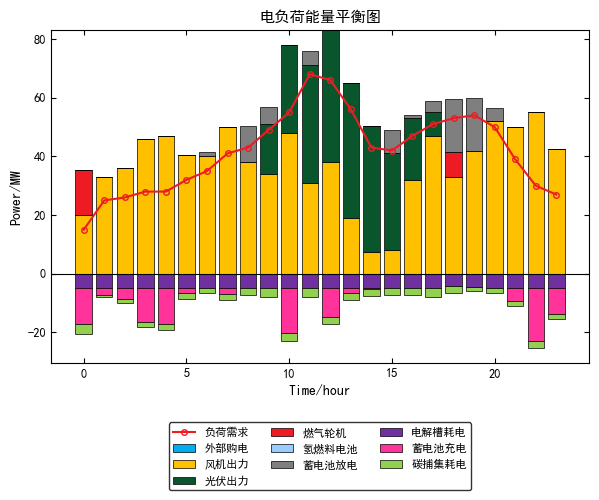

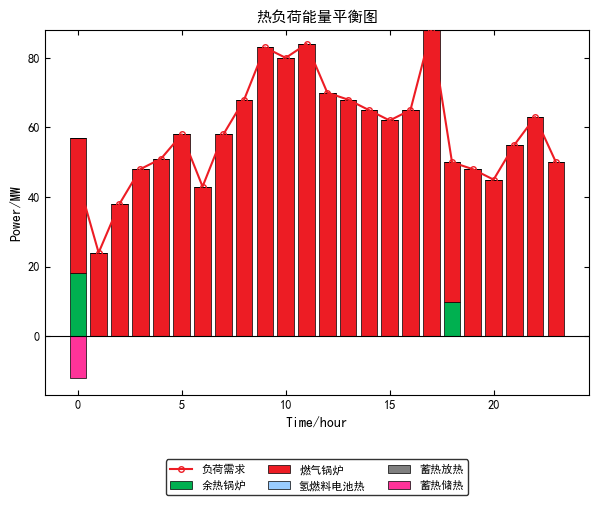

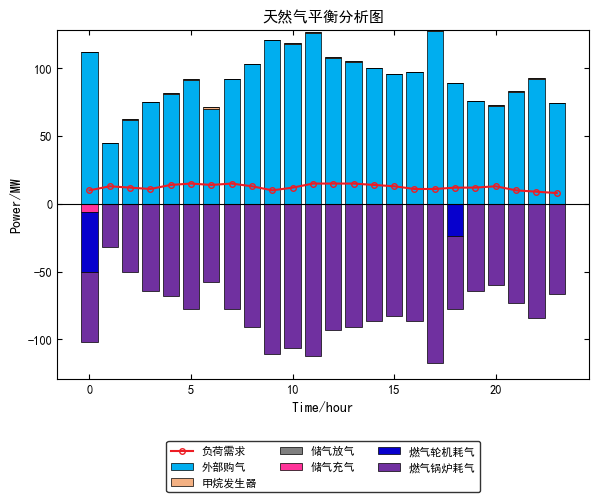

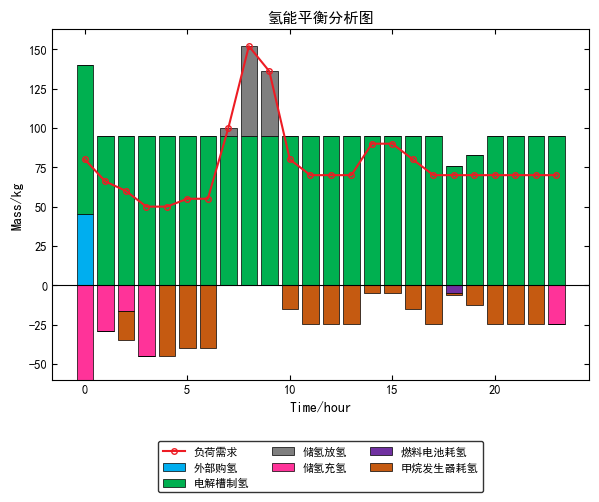

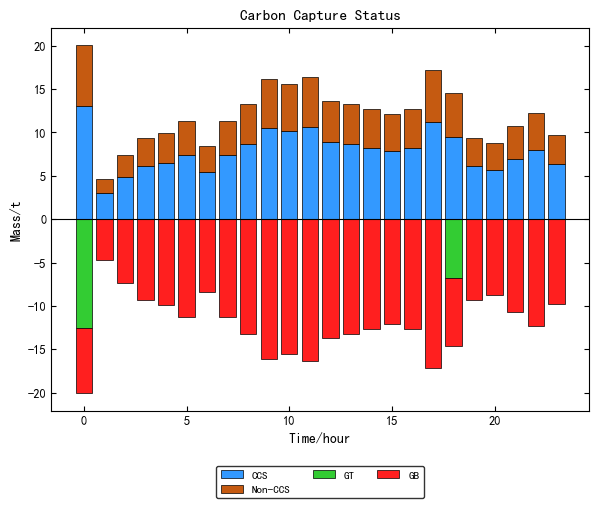

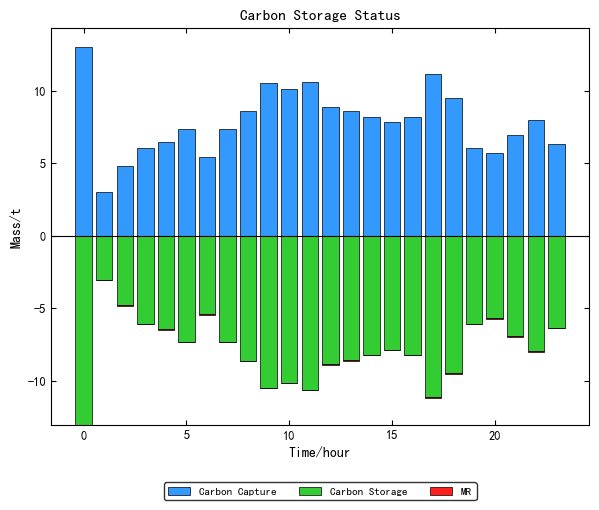

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gurobipy import GRB

# =========================
# 模型求解
# =========================
model.optimize()
if model.status != GRB.OPTIMAL:
    print("未得到最优解，status =", model.status)
else:
    print("最小总成本 ObjVal =", model.ObjVal)

    def vlist(vdict, T):
        """把 addVars 返回的 tupledict 取成长度T的list"""
        return [vdict[t].X for t in range(T)]

    # =========================
    # 1) 提取调度结果
    # =========================
    res = pd.DataFrame({"t": list(range(T))})
    # --- 电侧 ---
    res["E_Load"] = electric_load
    res["E_Buy"]  = vlist(Pbuy_e, T)
    res["WT"]     = vlist(PWT, T)
    res["PV"]     = vlist(PPV, T)
    res["GT_e"]   = vlist(PGT_e, T)
    res["HFC_e"]  = vlist(PHFC_e, T)
    res["ES1_dis"]= vlist(Pdis1, T)
    res["EL_e"]   = vlist(PEL_e, T)
    res["ES1_cha"]= vlist(Pcha1, T)
    res["CCS_e"]  = vlist(PCSSt, T)
    res["WT_cut"] = vlist(PWT_cut, T)
    res["PV_cut"] = vlist(PPV_cut, T)
    # --- 热侧 ---
    res["H_Load"] = thermal_load
    res["WHB_h"]  = vlist(PWHB_h, T)
    res["GB_h"]   = vlist(PGB_h, T)
    res["HFC_h"]  = vlist(PHFC_h, T)
    res["ES2_dis"]= vlist(Pdis2, T)
    res["ES2_cha"]= vlist(Pcha2, T)
    res["H_Buy"]    = vlist(Pbuy_h, T)
    # --- 气侧 ---
    res["G_Load"] = gas_load
    res["G_Buy"]  = vlist(Pbuy_g, T)
    res["MR_g"]   = vlist(PMR_g, T)
    res["ES3_dis"]= vlist(Pdis3, T)
    res["ES3_cha"]= vlist(Pcha3, T)
    res["GT_g"]   = vlist(PGT_g, T)
    res["GB_g"]   = vlist(PGB_g, T)
    # --- 氢侧 ---
    res["H2_Load"]= hydrogen_load
    res["H2_Buy"] = vlist(Pbuy_H, T)
    res["EL_H2"]  = vlist(HEL, T)
    res["ES4_dis"]= vlist(Pdis4, T)
    res["ES4_cha"]= vlist(Pcha4, T)
    res["HFC_H2"] = vlist(HHFC, T)
    res["MR_H2"]  = vlist(HMR, T)
    # --- CCS / 碳 ---
    res["ECO2"]       = vlist(ECO2, T)
    res["Ecap_CCS"]   = vlist(Ecap_CCS, T)
    res["Ecs_CCS"]    = vlist(Ecs_CCS, T)
    res["EMR"]        = vlist(EMR, T)
    res["ECS"]        = vlist(ECS, T)
    res["ECO2_env"]   = vlist(ECO2_env, T)
    res["EGT_a"] = vlist(EGT_a, T)   # GT实际碳排放
    res["EGB_a"] = vlist(EGB_a, T)   # GB实际碳排放
    # --- SOC ---
    res["SOC1"]= vlist(SOC1, T)
    res["SOC2"]= vlist(SOC2, T)
    res["SOC3"]= vlist(SOC3, T)
    res["SOC4"]= vlist(SOC4, T)

    # =========================
    # 2) 六大类成本统计
    # =========================
    cost_energy_purchase = sum(electricity_price[t]*Pbuy_e[t].X*dt + natural_gas_price*Pbuy_g[t].X*dt
                               + hydrogen_price*Pbuy_H[t].X*meh*dt + heat_price*Pbuy_h[t].X*dt for t in range(T))
    cost_device_om = sum(αGT*PGT_e[t].X*dt + αGB*PGB_h[t].X*dt + αWHB*PWHB_h[t].X*dt
                         + αEL*PEL_e[t].X*dt + αMR*PMR_g[t].X*dt + αHFC*PHFC_tot[t].X*dt
                         + αCCS*PCSSt[t].X*dt + αWT*PWT[t].X*dt + αPV*PPV[t].X*dt for t in range(T))
    cost_storage_om = sum(α1*(Pcha1[t].X+Pdis1[t].X)*dt + α2*(Pcha2[t].X+Pdis2[t].X)*dt
                          + α3*(Pcha3[t].X+Pdis3[t].X)*dt + α4*(Pcha4[t].X+Pdis4[t].X)*dt for t in range(T))
    cost_curtailment = sum(wind_penalty*PWT_cut[t].X*dt + solar_penalty*PPV_cut[t].X*dt for t in range(T))
    cost_carbon_storage = sum(kcs*ECS[t].X*dt for t in range(T))
    cost_carbon_trading = CCT.X

    print("\n========== 成本汇总 ==========")
    print(f"调度总成本 / 元: {model.ObjVal:.4f}")
    print(f"外购能源成本 / 元: {cost_energy_purchase:.4f}")
    print(f"设备运维成本 / 元: {cost_device_om:.4f}")
    print(f"储能运维成本 / 元: {cost_storage_om:.4f}")
    print(f"弃风弃光惩罚 / 元: {cost_curtailment:.4f}")
    print(f"碳封存成本 / 元: {cost_carbon_storage:.4f}")
    print(f"阶梯碳交易成本 / 元: {cost_carbon_trading:.4f}")

    # =========================
    # 3) 学术风格绘图
    # =========================

    # --- 环境设置 ---
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # --- 颜色表 ---
    COLOR_MAP = {
        "外部购电": "#00AEEF", "外部购气": "#00AEEF", "外部购氢": "#00AEEF",
        "风机出力": "#FFC000", "光伏出力": "#0A562C",
        "燃气轮机": "#ED1C24", "燃气锅炉": "#ED1C24", "甲烷发生器": "#F4B183",
        "余热锅炉": "#00B050", "电解槽制氢": "#00B050", "碳捕集耗电": "#92D050",
        "氢燃料电池": "#99CCFF", "氢燃料电池热": "#99CCFF",
        "蓄电池放电": "#7F7F7F", "蓄热放热": "#7F7F7F", "储气放气": "#7F7F7F", "储氢放氢": "#7F7F7F",
        "蓄电池充电": "#FF3399", "蓄热储热": "#FF3399", "储气充气": "#FF3399", "储氢充氢": "#FF3399",
        "电解槽耗电": "#7030A0", "燃气轮机耗气": "#0700CD", "燃气锅炉耗气": "#7030A0", "燃料电池耗氢": "#7030A0", "甲烷发生器耗氢": "#C55A11",
        "CCS": "#3399FF", "Non-CCS": "#C55A11", "GT": "#33CC33", "GB": "#FF1F1F",
        "Carbon Capture": "#3399FF", "Carbon Storage": "#33CC33", "MR": "#FF1F1F"
    }

    def plot_balance_stack_final(t, pos_dict, neg_dict, load, title, ylabel):
        x = np.array(t)
        fig, ax = plt.subplots(figsize=(6.09, 5.21), dpi=100)
        bottom_pos = np.zeros_like(x, dtype=float)
        for k, v in pos_dict.items():
            color = COLOR_MAP.get(k, "#A6A6A6")
            ax.bar(x, v, bottom=bottom_pos, label=k, color=color, edgecolor='black', linewidth=0.5, zorder=2)
            bottom_pos += np.array(v, dtype=float)
        bottom_neg = np.zeros_like(x, dtype=float)
        for k, v in neg_dict.items():
            v_neg = -np.array(v, dtype=float)
            color = COLOR_MAP.get(k, "#D9D9D9")
            ax.bar(x, v_neg, bottom=bottom_neg, label=k, color=color, edgecolor='black', linewidth=0.5, zorder=2)
            bottom_neg += v_neg
        ax.plot(x, load, color='#ED1C24', marker="o", markerfacecolor='none', markeredgecolor='#ED1C24',
                markersize=4, linewidth=1.5, label="负荷需求", zorder=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel("Time/hour", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=9)
        ax.axhline(0, color='black', linewidth=0.8, zorder=3)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=True, edgecolor='black', fontsize=8)
        plt.tight_layout()
        plt.show()

    def plot_carbon_stack_final(t, pos_dict, neg_dict, title, ylabel):
        x = np.array(t)
        fig, ax = plt.subplots(figsize=(6.09, 5.21), dpi=100)
        bottom_pos = np.zeros_like(x, dtype=float)
        for k, v in pos_dict.items():
            color = COLOR_MAP.get(k, "#A6A6A6")
            ax.bar(x, v, bottom=bottom_pos, label=k, color=color, edgecolor='black', linewidth=0.5, zorder=2)
            bottom_pos += np.array(v, dtype=float)
        bottom_neg = np.zeros_like(x, dtype=float)
        for k, v in neg_dict.items():
            v_neg = -np.array(v, dtype=float)
            color = COLOR_MAP.get(k, "#D9D9D9")
            ax.bar(x, v_neg, bottom=bottom_neg, label=k, color=color, edgecolor='black', linewidth=0.5, zorder=2)
            bottom_neg += v_neg
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel("Time/hour", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=9)
        ax.axhline(0, color='black', linewidth=0.8, zorder=3)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=True, edgecolor='black', fontsize=8)
        plt.tight_layout()
        plt.show()

    # =========================
    # 电 / 热 / 气 / 氢平衡图
    # =========================
    plot_balance_stack_final(
        res["t"],
        {"外部购电": res["E_Buy"], "风机出力": res["WT"], "光伏出力": res["PV"], "燃气轮机": res["GT_e"], "氢燃料电池": res["HFC_e"], "蓄电池放电": res["ES1_dis"]},
        {"电解槽耗电": res["EL_e"], "蓄电池充电": res["ES1_cha"], "碳捕集耗电": res["CCS_e"]},
        res["E_Load"], "电负荷能量平衡图", "Power/MW"
    )

    plot_balance_stack_final(
        res["t"],
        {"余热锅炉": res["WHB_h"], "燃气锅炉": res["GB_h"], "氢燃料电池热": res["HFC_h"], "蓄热放热": res["ES2_dis"]},
        {"蓄热储热": res["ES2_cha"]},
        res["H_Load"], "热负荷能量平衡图", "Power/MW"
    )

    plot_balance_stack_final(
        res["t"],
        {"外部购气": res["G_Buy"], "甲烷发生器": res["MR_g"], "储气放气": res["ES3_dis"]},
        {"储气充气": res["ES3_cha"], "燃气轮机耗气": res["GT_g"], "燃气锅炉耗气": res["GB_g"]},
        res["G_Load"], "天然气平衡分析图", "Power/MW"
    )

    plot_balance_stack_final(
        res["t"],
        {"外部购氢": res["H2_Buy"], "电解槽制氢": res["EL_H2"], "储氢放氢": res["ES4_dis"]},
        {"储氢充氢": res["ES4_cha"], "燃料电池耗氢": res["HFC_H2"], "甲烷发生器耗氢": res["MR_H2"]},
        res["H2_Load"], "氢能平衡分析图", "Mass/kg"
    )

    # =========================
    # 碳图：严格按论文画法，无负荷线
    # =========================

    # (e) Carbon Capture Status
    # 正向：CCS、Non-CCS
    # 负向：GT、GB
    plot_carbon_stack_final(
        res["t"],
        {"CCS": res["Ecap_CCS"], "Non-CCS": res["Ecs_CCS"]},
        {"GT": res["EGT_a"], "GB": res["EGB_a"]},
        "Carbon Capture Status", "Mass/t"
    )

    # (f) Carbon Storage Status
    # 正向：Carbon Capture
    # 负向：Carbon Storage、MR
    plot_carbon_stack_final(
        res["t"],
        {"Carbon Capture": res["Ecap_CCS"]},
        {"Carbon Storage": res["ECS"], "MR": res["EMR"]},
        "Carbon Storage Status", "Mass/t"
    )